# Flux Tests & Photometry of Lensing Galaxies

This notebook has two parts:

1. **Demonstrating `test_flux.py`** — Walking through each test to show how mejiro's flux/magnitude pipeline works.
2. **Aperture photometry** — Measuring the lensing galaxy brightness in SampleGG, Sample1, and Sample2 and comparing to the known `get_lens_magnitude(band)` values.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import mejiro
from mejiro.galaxy_galaxy import SampleGG, Sample1, Sample2
from mejiro.instruments.roman import Roman
from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.analysis.lens_subtraction import fit_sersic, subtract_lens, plot_lens_subtraction
from lenstronomy.Util import data_util

TEST_DATA_DIR = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'tests', 'test_data')

## Part 1: Demonstrating `test_flux.py`

The test suite validates that mejiro's imaging pipeline conserves flux at every stage. We'll reproduce each test interactively.

### Helper: create a noiseless exposure

The tests use a helper that builds a `SyntheticImage` with a real STPSF Roman PSF, then creates an `Exposure` with **all noise and detector effects disabled**. This isolates the flux pipeline from stochastic noise.

In [2]:
def make_noiseless_exposure(strong_lens, band='F129', exposure_time=146, pieces=True):
    """Create a noiseless exposure for flux testing (mirrors test_flux._make_noiseless_exposure)."""
    detector = 'SCA01'
    detector_position = (2048, 2048)

    # get a real Roman PSF from STPSF (cached)
    kwargs_psf = STPSFEngine.get_roman_psf_kwargs(
        band, detector, detector_position, oversample=5, num_pix=101,
        check_cache=True, psf_cache_dir=TEST_DATA_DIR, verbose=False)

    synthetic_image = SyntheticImage(
        strong_lens=strong_lens,
        instrument=Roman(),
        band=band,
        fov_arcsec=5,
        instrument_params={'detector': detector, 'detector_position': detector_position},
        kwargs_numerics={},
        kwargs_psf=kwargs_psf,
        pieces=pieces,
        verbose=True)

    # disable all noise and detector effects
    engine_params = {
        'sky_background': False,
        'detector_effects': False,
    }
    exposure = Exposure(
        synthetic_image,
        exposure_time=exposure_time,
        engine='galsim',
        engine_params=engine_params,
        verbose=True)

    return synthetic_image, exposure

In [3]:
# build the SampleGG lens and noiseless exposure (used by all tests below)
strong_lens = SampleGG()
band = 'F129'
exposure_time = 146

synthetic_image, exposure = make_noiseless_exposure(strong_lens, band=band, exposure_time=exposure_time)

Scene size: 5.17 arcsec, 47 pixels at pixel scale 0.11 arcsec/pix
Synthetic image calculation time: 0.242 s
Exposure calculation time with galsim engine: 0.049 s


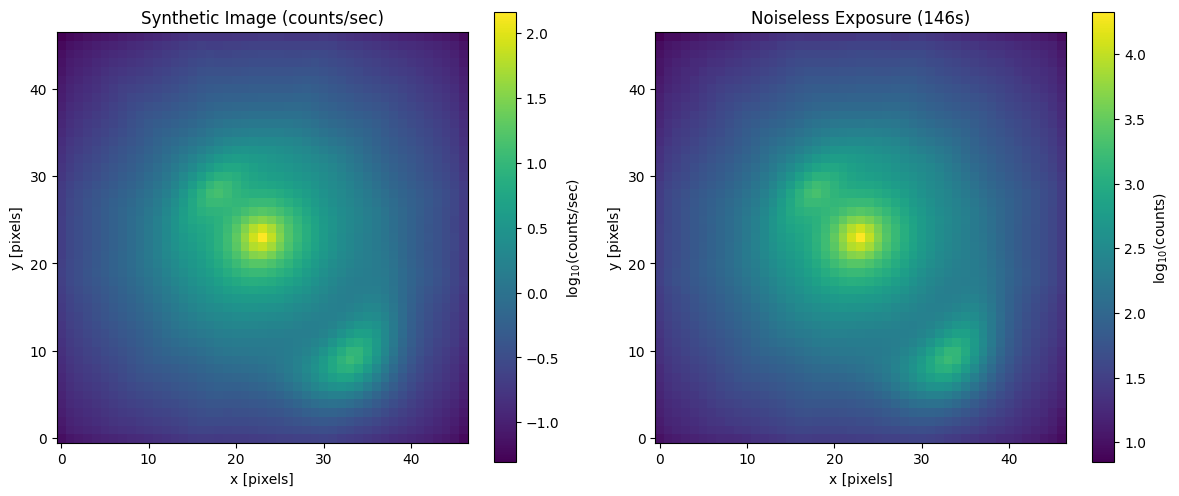

In [4]:
# visualize the synthetic image and noiseless exposure side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(np.log10(np.clip(synthetic_image.image, 1e-10, None)), origin='lower', cmap='viridis')
axes[0].set_title('Synthetic Image (counts/sec)')
fig.colorbar(im0, ax=axes[0], label=r'log$_{10}$(counts/sec)')

im1 = axes[1].imshow(np.log10(np.clip(exposure.exposure, 1, None)), origin='lower', cmap='viridis')
axes[1].set_title(f'Noiseless Exposure ({exposure_time}s)')
fig.colorbar(im1, ax=axes[1], label=r'log$_{10}$(counts)')

for ax in axes:
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')
plt.tight_layout()
plt.show()

### Test 1: `test_noiseless_exposure_flux`

With all noise disabled, the exposure should equal `synthetic_image.image * exposure_time`, with only integer quantization error (at most 0.5 counts per pixel from rounding).

In [5]:
expected_total = np.sum(synthetic_image.image) * exposure_time
actual_total = np.sum(exposure.exposure)

max_quantization_error = 0.5 * synthetic_image.num_pix ** 2

print(f'Expected total flux:    {expected_total:.1f} counts')
print(f'Actual total flux:      {actual_total:.1f} counts')
print(f'Absolute difference:    {abs(actual_total - expected_total):.1f} counts')
print(f'Max quantization error: {max_quantization_error:.1f} counts')
print(f'PASS: {abs(actual_total - expected_total) < max_quantization_error}')

Expected total flux:    615144.6 counts
Actual total flux:      615153.0 counts
Absolute difference:    8.4 counts
Max quantization error: 1104.5 counts
PASS: True


### Test 2: `test_pieces_sum_to_total`

When `pieces=True`, lenstronomy renders the lens light and lensed source light separately. Their sum should equal the total image to machine precision.

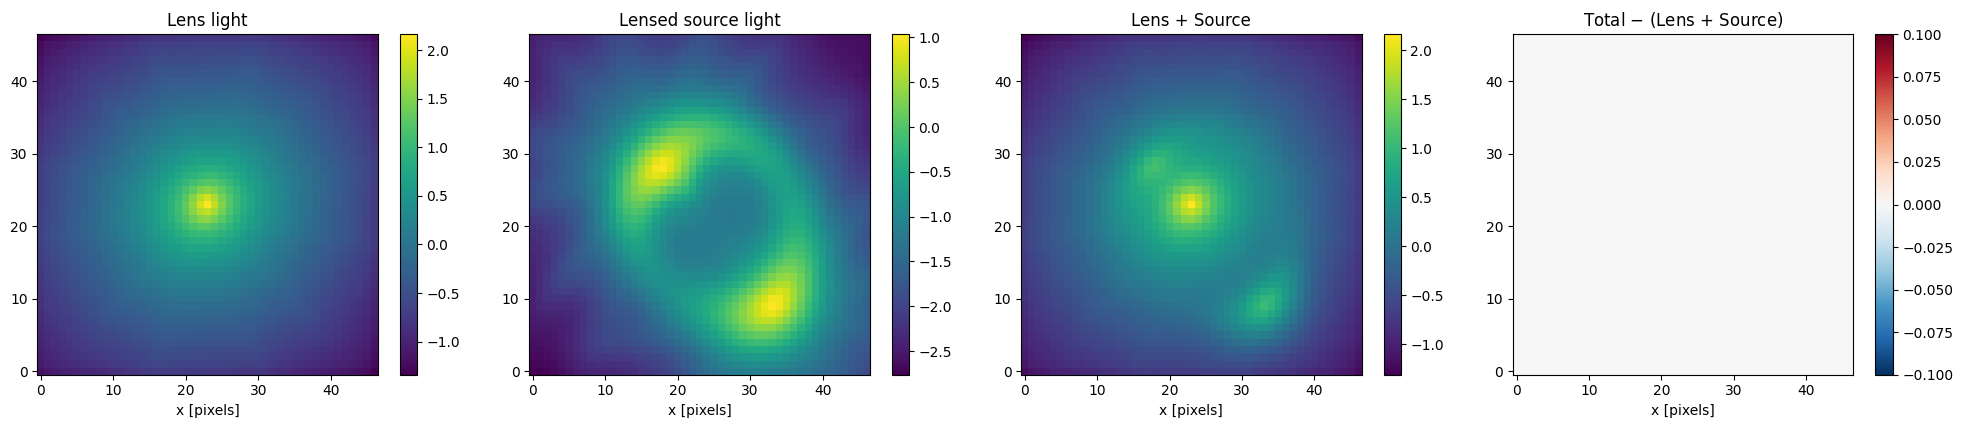

Max |residual|: 0.00e+00 counts/sec
PASS: True


In [6]:
pieces_sum = synthetic_image.lens_surface_brightness + synthetic_image.source_surface_brightness
residual = synthetic_image.image - pieces_sum

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
im0 = axes[0].imshow(np.log10(np.clip(synthetic_image.lens_surface_brightness, 1e-10, None)), origin='lower')
axes[0].set_title('Lens light')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.log10(np.clip(synthetic_image.source_surface_brightness, 1e-10, None)), origin='lower')
axes[1].set_title('Lensed source light')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.log10(np.clip(pieces_sum, 1e-10, None)), origin='lower')
axes[2].set_title('Lens + Source')
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(residual, origin='lower', cmap='RdBu_r')
axes[3].set_title('Total $-$ (Lens + Source)')
fig.colorbar(im3, ax=axes[3])

for ax in axes:
    ax.set_xlabel('x [pixels]')
plt.tight_layout()
plt.show()

max_residual = np.max(np.abs(residual))
print(f'Max |residual|: {max_residual:.2e} counts/sec')
print(f'PASS: {np.allclose(synthetic_image.image, pieces_sum, rtol=1e-10)}')

### Test 3: `test_lens_magnitude`

Sum the lens surface brightness (counts/sec), convert back to a magnitude using the zero-point, and compare to the input `get_lens_magnitude(band)`. The tolerance of 0.2 mag accounts for finite FOV truncation of the Sersic profile.

In [14]:
# input lens magnitude
expected_lens_mag = strong_lens.get_lens_magnitude(band)

# sum the lens-only surface brightness to get total lens flux in counts/sec
lens_flux_cps = np.sum(synthetic_image.lens_surface_brightness)

# convert back to magnitude via the zero-point
measured_lens_mag = data_util.cps2magnitude(lens_flux_cps, synthetic_image.magnitude_zeropoint)[0]

print(f'Expected lens magnitude ({band}): {expected_lens_mag}')
print(f'Measured lens magnitude ({band}): {measured_lens_mag:.4f}')
print(f'Difference:                       {abs(measured_lens_mag - expected_lens_mag):.4f} mag')
print(f'PASS (< 0.2 mag):                 {abs(measured_lens_mag - expected_lens_mag) < 0.2}')

Expected lens magnitude (F129): 17.3
Measured lens magnitude (F129): 17.4591
Difference:                       0.1591 mag
PASS (< 0.2 mag):                 True


### Test 4: `test_source_magnitude`

The lensed source should be magnified — brighter (lower magnitude) than the unlensed input source magnitude.

In [15]:
unlensed_source_mag = strong_lens.get_source_magnitude(band)

source_flux_cps = np.sum(synthetic_image.source_surface_brightness)
measured_source_mag = data_util.cps2magnitude(source_flux_cps, synthetic_image.magnitude_zeropoint)[0]

magnification_mag = unlensed_source_mag - measured_source_mag

print(f'Unlensed source magnitude ({band}): {unlensed_source_mag}')
print(f'Measured lensed source magnitude:    {measured_source_mag:.4f}')
print(f'Magnification (mag):                 {magnification_mag:.4f} (= {10**(0.4 * magnification_mag):.2f}x flux boost)')
print(f'PASS (lensed brighter):              {measured_source_mag < unlensed_source_mag}')

Unlensed source magnitude (F129): 21.1
Measured lensed source magnitude:    19.1870
Magnification (mag):                 1.9130 (= 5.82x flux boost)
PASS (lensed brighter):              True


### Test 5: `test_total_image_maggies`

Maggies are a linear flux unit: $m_\mathrm{maggies} = 10^{-0.4\,m}$. Since flux is additive in linear space, the total maggies should equal the sum of lens maggies + source maggies.

In [16]:
total_maggies = synthetic_image.get_maggies()

# compute maggies from individual components
lens_mag = data_util.cps2magnitude(lens_flux_cps, synthetic_image.magnitude_zeropoint)
source_mag = data_util.cps2magnitude(source_flux_cps, synthetic_image.magnitude_zeropoint)

lens_maggies = 10 ** (-0.4 * lens_mag)
source_maggies = 10 ** (-0.4 * source_mag)
expected_maggies = (lens_maggies + source_maggies).item()

print(f'Total maggies (get_maggies):           {total_maggies:.8e}')
print(f'Lens maggies:                          {lens_maggies.item():.8e}')
print(f'Source maggies:                        {source_maggies.item():.8e}')
print(f'Sum of component maggies:              {expected_maggies:.8e}')
print(f'Relative difference:                   {abs(total_maggies - expected_maggies) / expected_maggies:.2e}')
print(f'PASS (rtol < 1e-5):                    {np.allclose(total_maggies, expected_maggies, rtol=1e-5)}')

Total maggies (get_maggies):           1.24986605e-07
Lens maggies:                          1.03842792e-07
Source maggies:                        2.11438138e-08
Sum of component maggies:              1.24986605e-07
Relative difference:                   8.47e-16
PASS (rtol < 1e-5):                    True


### Test 6: `test_exposure_counts_match_synthetic_flux`

The noiseless exposure total counts should equal `get_flux() * exposure_time` to within 0.1% (quantization error).

In [17]:
expected_counts = synthetic_image.get_flux() * exposure_time
actual_counts = np.sum(exposure.exposure)
relative_error = abs(actual_counts - expected_counts) / expected_counts

print(f'Expected counts (get_flux * t_exp): {expected_counts:.1f}')
print(f'Actual exposure counts:             {actual_counts:.1f}')
print(f'Relative error:                     {relative_error:.6e}')
print(f'PASS (< 1e-3):                      {relative_error < 1e-3}')

Expected counts (get_flux * t_exp): 615144.6
Actual exposure counts:             615153.0
Relative error:                     1.368196e-05
PASS (< 1e-3):                      True


---

## Part 2: Aperture Photometry on Lensing Galaxies

We now perform photometry on the **lens-only** surface brightness of each sample system (SampleGG, Sample1, Sample2) and verify the measured magnitudes match `get_lens_magnitude(band)`.

**Strategy:**
- Use the `lens_surface_brightness` array (lens light only, no source contamination) from the synthetic image with `pieces=True`.
- **Aperture photometry**: sum flux within circular apertures of varying radii using `photutils`.
- Compare to the known input magnitude from `get_lens_magnitude(band)`.

In [ ]:
from photutils.aperture import CircularAperture, aperture_photometry

### Generate synthetic images for all three samples

In [ ]:
samples = {
    'SampleGG': SampleGG(),
    'Sample1': Sample1(),
    'Sample2': Sample2(),
}

band = 'F129'
detector = 'SCA01'
detector_position = (2048, 2048)

# get PSF kernel (shared across all samples for this band/detector)
kwargs_psf = STPSFEngine.get_roman_psf_kwargs(
    band, detector, detector_position, oversample=5, num_pix=101,
    check_cache=True, psf_cache_dir=TEST_DATA_DIR, verbose=False)

In [58]:
fov_arcsec = 10

# generate synthetic images for each sample
synth_images = {}
for name, sl in samples.items():
    print(f'\n--- {name} ---')
    si = SyntheticImage(
        strong_lens=sl,
        instrument=Roman(),
        band=band,
        fov_arcsec=fov_arcsec,
        instrument_params={'detector': detector, 'detector_position': detector_position},
        kwargs_numerics={},
        kwargs_psf=kwargs_psf,
        pieces=True,
        verbose=True)
    synth_images[name] = si


--- SampleGG ---
Scene size: 10.01 arcsec, 91 pixels at pixel scale 0.11 arcsec/pix
Synthetic image calculation time: 0.168 s

--- Sample1 ---
Scene size: 10.01 arcsec, 91 pixels at pixel scale 0.11 arcsec/pix
Synthetic image calculation time: 1.027 s

--- Sample2 ---
Scene size: 10.01 arcsec, 91 pixels at pixel scale 0.11 arcsec/pix
Synthetic image calculation time: 1.003 s


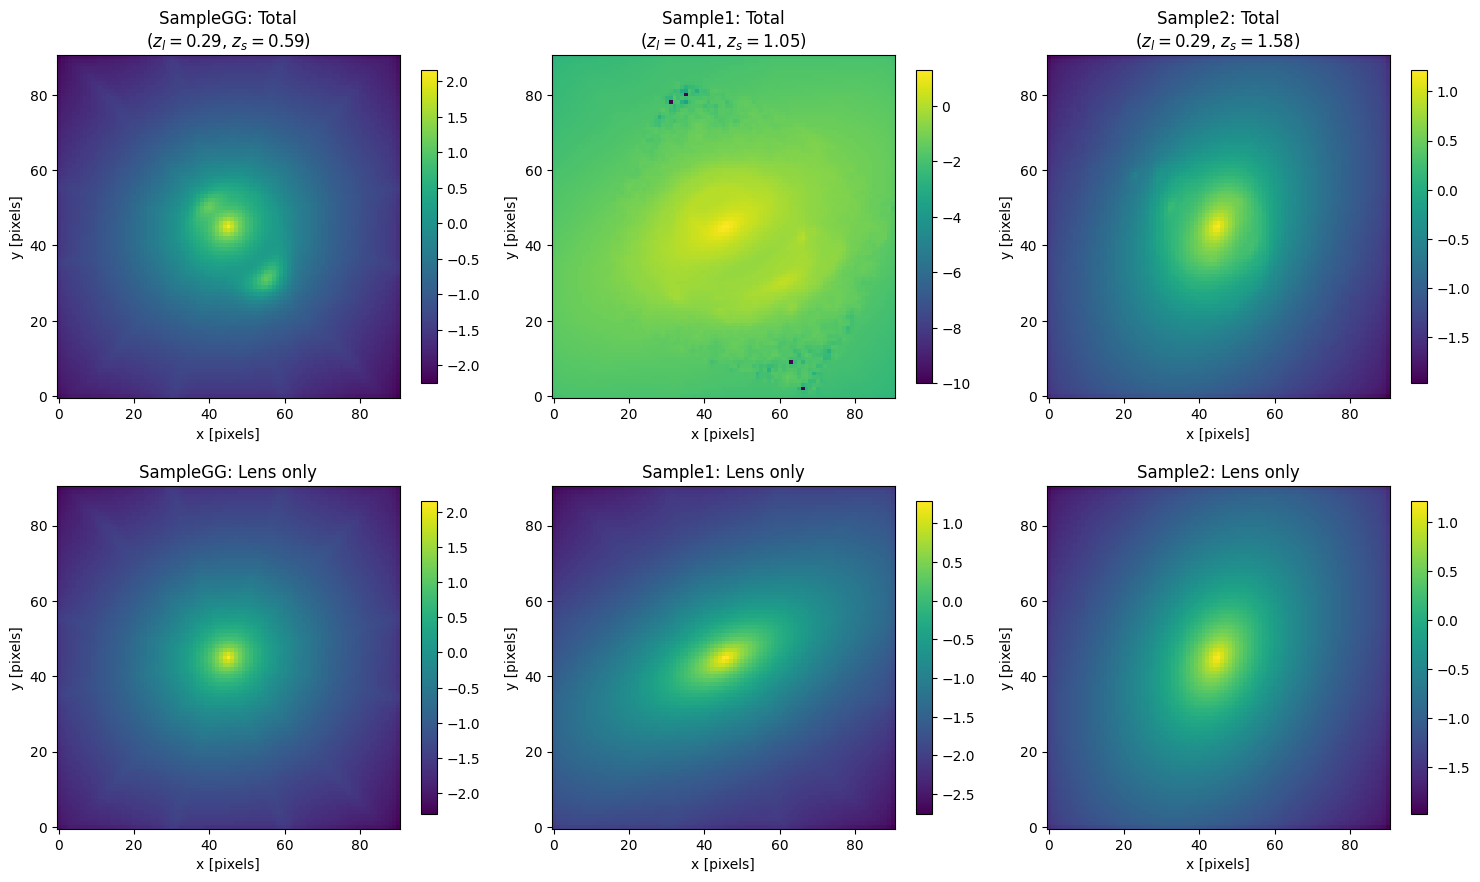

In [59]:
# visualize all three lens systems
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, (name, si) in enumerate(synth_images.items()):
    sl = samples[name]
    
    # total image
    im = axes[0, i].imshow(np.log10(np.clip(si.image, 1e-10, None)), origin='lower', cmap='viridis')
    axes[0, i].set_title(f'{name}: Total\n($z_l={sl.z_lens:.2f}$, $z_s={sl.z_source:.2f}$)')
    fig.colorbar(im, ax=axes[0, i], shrink=0.8)
    
    # lens-only light
    im = axes[1, i].imshow(np.log10(np.clip(si.lens_surface_brightness, 1e-10, None)), origin='lower', cmap='viridis')
    axes[1, i].set_title(f'{name}: Lens only')
    fig.colorbar(im, ax=axes[1, i], shrink=0.8)

for ax in axes.flat:
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')
plt.tight_layout()
plt.show()

### Aperture Photometry

We perform circular aperture photometry on the **lens-only** surface brightness maps. We use a range of aperture radii to show convergence, and compare the asymptotic magnitude to the input value.

In [60]:
def aperture_photometry_curve(image, center, radii_pix, magnitude_zeropoint):
    """Measure aperture photometry at a range of radii and return magnitudes."""
    mags = []
    fluxes = []
    for r in radii_pix:
        aperture = CircularAperture(center, r=r)
        phot = aperture_photometry(image, aperture)
        flux_cps = phot['aperture_sum'][0]
        fluxes.append(flux_cps)
        if flux_cps > 0:
            mag = data_util.cps2magnitude(flux_cps, magnitude_zeropoint)
            mags.append(float(mag))
        else:
            mags.append(np.nan)
    return np.array(radii_pix), np.array(fluxes), np.array(mags)

/tmp/ipykernel_1529444/3058053526.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mags.append(float(mag))
/tmp/ipykernel_1529444/3058053526.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mags.append(float(mag))
/tmp/ipykernel_1529444/3058053526.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mags.append(float(mag))
/tmp/ipykernel_1529444/3058053526.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will er

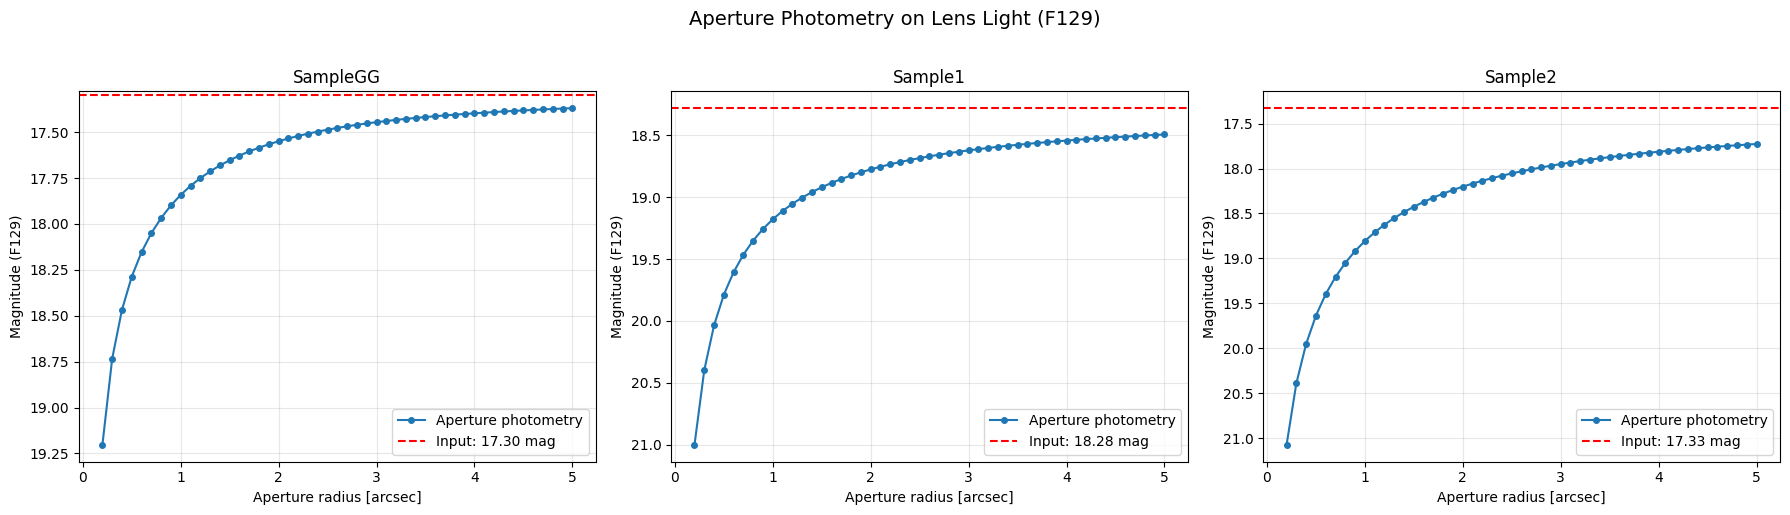

In [61]:
pixel_scale = Roman().get_pixel_scale(band).value  # arcsec/pix
radii_arcsec = np.arange(0.2, (fov_arcsec / 2) + 0.1, 0.1)
radii_pix = radii_arcsec / pixel_scale

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

aperture_results = {}

for i, (name, si) in enumerate(synth_images.items()):
    sl = samples[name]
    center = (si.num_pix // 2, si.num_pix // 2)
    
    radii, fluxes, mags = aperture_photometry_curve(
        si.lens_surface_brightness, center, radii_pix, si.magnitude_zeropoint)
    
    expected_mag = sl.get_lens_magnitude(band)
    
    # store the largest-aperture result
    aperture_results[name] = {
        'measured_mag': mags[-1],
        'expected_mag': expected_mag,
    }
    
    ax = axes[i]
    ax.plot(radii_arcsec, mags, 'o-', label='Aperture photometry', markersize=4)
    ax.axhline(expected_mag, color='r', ls='--', label=f'Input: {expected_mag:.2f} mag')
    ax.set_xlabel('Aperture radius [arcsec]')
    ax.set_ylabel(f'Magnitude ({band})')
    ax.set_title(f'{name}')
    ax.invert_yaxis()
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Aperture Photometry on Lens Light ({band})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [62]:
# print aperture photometry summary
print(f'{"Sample":<12} {"Expected mag":>14} {"Aperture mag":>14} {"Difference":>12}')
print('-' * 56)
for name, res in aperture_results.items():
    diff = abs(res['measured_mag'] - res['expected_mag'])
    print(f'{name:<12} {res["expected_mag"]:>14.3f} {res["measured_mag"]:>14.3f} {diff:>12.3f}')

Sample         Expected mag   Aperture mag   Difference
--------------------------------------------------------
SampleGG             17.300         17.370        0.070
Sample1              18.282         18.495        0.212
Sample2              17.329         17.728        0.398


### Comparison: pixel sum vs. aperture photometry

In [63]:
# compute pixel-sum magnitudes (the "ground truth" from the synthetic image)
pixel_sum_results = {}
for name, si in synth_images.items():
    sl = samples[name]
    flux_cps = np.sum(si.lens_surface_brightness)
    mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
    pixel_sum_results[name] = mag

# summary table
print(f'{"Sample":<12} {"Input mag":>10} {"Pixel sum":>10} {"Aperture":>10}')
print('-' * 46)
for name in samples:
    expected = samples[name].get_lens_magnitude(band)
    pix = pixel_sum_results[name]
    aper = aperture_results[name]['measured_mag']
    print(f'{name:<12} {expected:>10.3f} {pix:>10.3f} {aper:>10.3f}')

Sample        Input mag  Pixel sum   Aperture
----------------------------------------------
SampleGG         17.300     17.359     17.370
Sample1          18.282     18.474     18.495
Sample2          17.329     17.693     17.728


/tmp/ipykernel_1529444/1324646802.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))


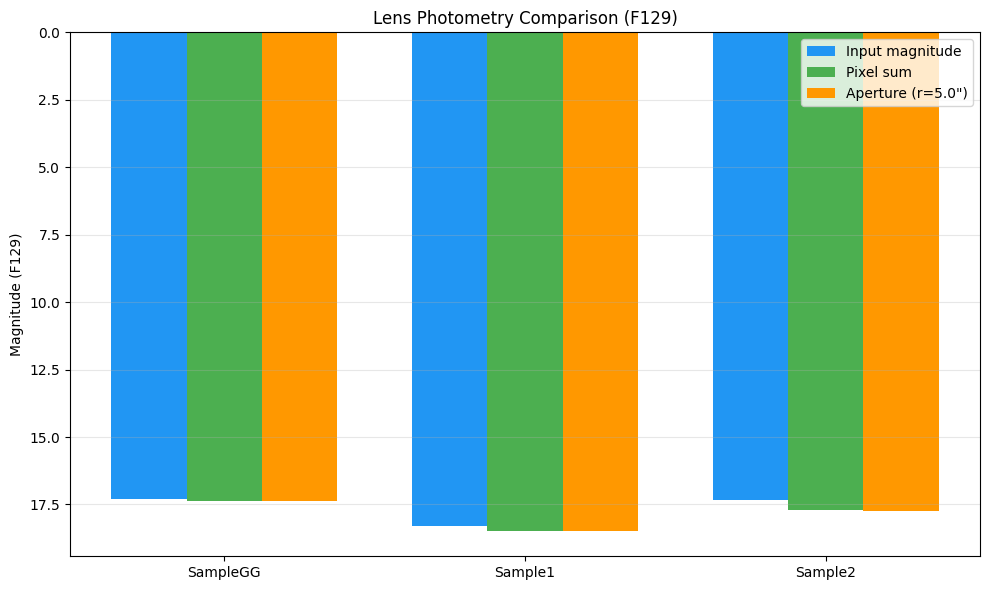

In [64]:
# bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(samples))
width = 0.25

input_mags = [samples[n].get_lens_magnitude(band) for n in samples]
pix_mags = [pixel_sum_results[n] for n in samples]
aper_mags = [aperture_results[n]['measured_mag'] for n in samples]

ax.bar(x - width, input_mags, width, label='Input magnitude', color='#2196F3')
ax.bar(x, pix_mags, width, label='Pixel sum', color='#4CAF50')
ax.bar(x + width, aper_mags, width, label=f'Aperture (r={fov_arcsec / 2:.1f}")', color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(samples.keys())
ax.set_ylabel(f'Magnitude ({band})')
ax.set_title(f'Lens Photometry Comparison ({band})')
ax.legend()
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Multi-band verification

Run the same analysis across multiple Roman bands to verify consistency.

In [65]:
roman_bands = ['F087', 'F106', 'F129', 'F158', 'F184']

multiband_results = {name: {'expected': [], 'pixel_sum': [], 'aperture': []} for name in samples}

for b in roman_bands:
    print(f'\n=== Band {b} ===')
    
    kw_psf = STPSFEngine.get_roman_psf_kwargs(
        b, detector, detector_position, oversample=5, num_pix=101,
        check_cache=True, psf_cache_dir=TEST_DATA_DIR, verbose=False)
    
    for name in samples:
        sl_fresh = type(samples[name])()  # fresh instance (amplitudes get overwritten)
        
        si = SyntheticImage(
            strong_lens=sl_fresh,
            instrument=Roman(),
            band=b,
            fov_arcsec=5,
            instrument_params={'detector': detector, 'detector_position': detector_position},
            kwargs_numerics={},
            kwargs_psf=kw_psf,
            pieces=True,
            verbose=False)
        
        expected_mag = sl_fresh.get_lens_magnitude(b)
        
        # pixel sum
        flux_cps = np.sum(si.lens_surface_brightness)
        pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
        
        # aperture photometry (large aperture)
        center = (si.num_pix // 2, si.num_pix // 2)
        aperture = CircularAperture(center, r=2.5 / si.pixel_scale)
        phot = aperture_photometry(si.lens_surface_brightness, aperture)
        aper_flux = phot['aperture_sum'][0]
        aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))
        
        multiband_results[name]['expected'].append(expected_mag)
        multiband_results[name]['pixel_sum'].append(pix_mag)
        multiband_results[name]['aperture'].append(aper_mag)
        
        print(f'  {name} {b}: expected={expected_mag:.3f}, pixel_sum={pix_mag:.3f}, aperture={aper_mag:.3f}')


=== Band F087 ===


/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))


  SampleGG F087: expected=17.700, pixel_sum=17.851, aperture=17.879


/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))


  Sample1 F087: expected=18.929, pixel_sum=19.279, aperture=19.324


...

/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude

  Sample2 F158: expected=17.117, pixel_sum=17.781, aperture=17.857

=== Band F184 ===
  SampleGG F184: expected=17.000, pixel_sum=17.174, aperture=17.206


/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))


  Sample1 F184: expected=17.948, pixel_sum=18.324, aperture=18.372
  Sample2 F184: expected=17.007, pixel_sum=17.681, aperture=17.757


/tmp/ipykernel_1529444/74480978.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pix_mag = float(data_util.cps2magnitude(flux_cps, si.magnitude_zeropoint))
/tmp/ipykernel_1529444/74480978.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aper_mag = float(data_util.cps2magnitude(aper_flux, si.magnitude_zeropoint))


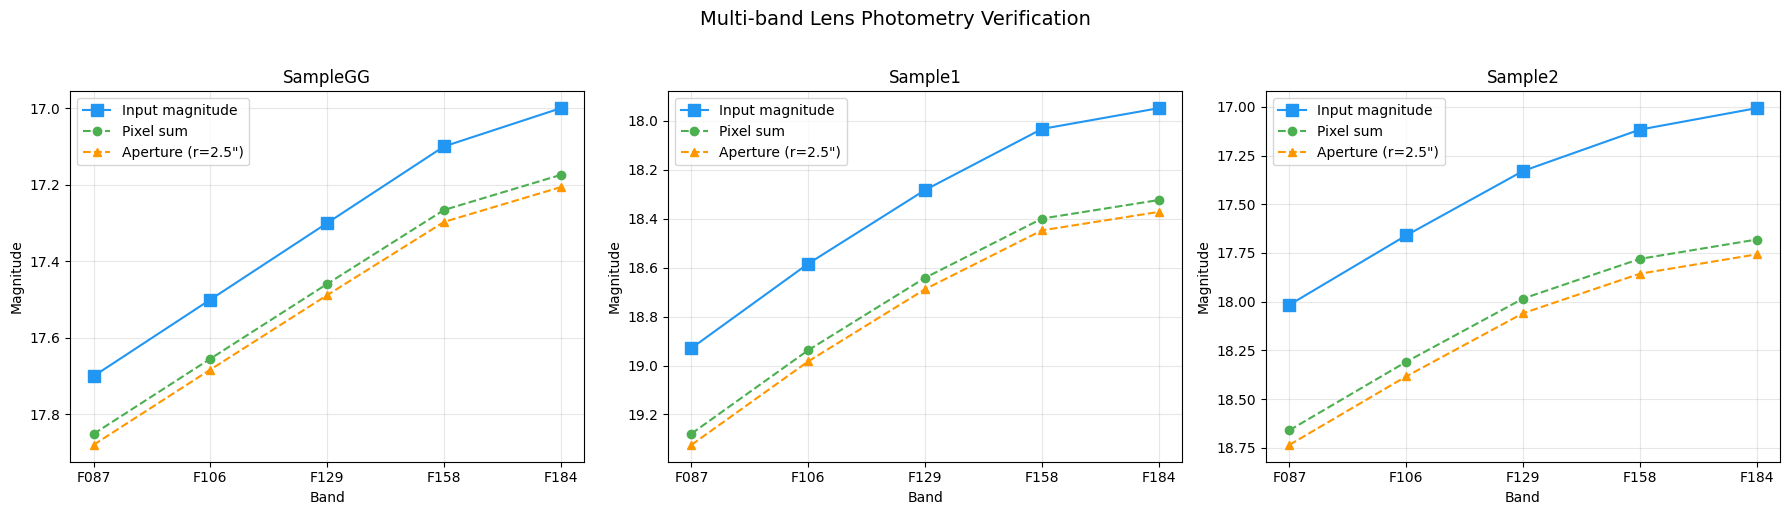

In [66]:
# plot multi-band results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(samples):
    ax = axes[i]
    res = multiband_results[name]
    
    ax.plot(roman_bands, res['expected'], 's-', label='Input magnitude', color='#2196F3', markersize=8)
    ax.plot(roman_bands, res['pixel_sum'], 'o--', label='Pixel sum', color='#4CAF50', markersize=6)
    ax.plot(roman_bands, res['aperture'], '^--', label='Aperture (r=2.5")', color='#FF9800', markersize=6)
    
    ax.set_xlabel('Band')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'{name}')
    ax.invert_yaxis()
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-band Lens Photometry Verification', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Residual analysis

Plot the pixel-sum and aperture magnitude residuals (measured $-$ expected) across all bands.

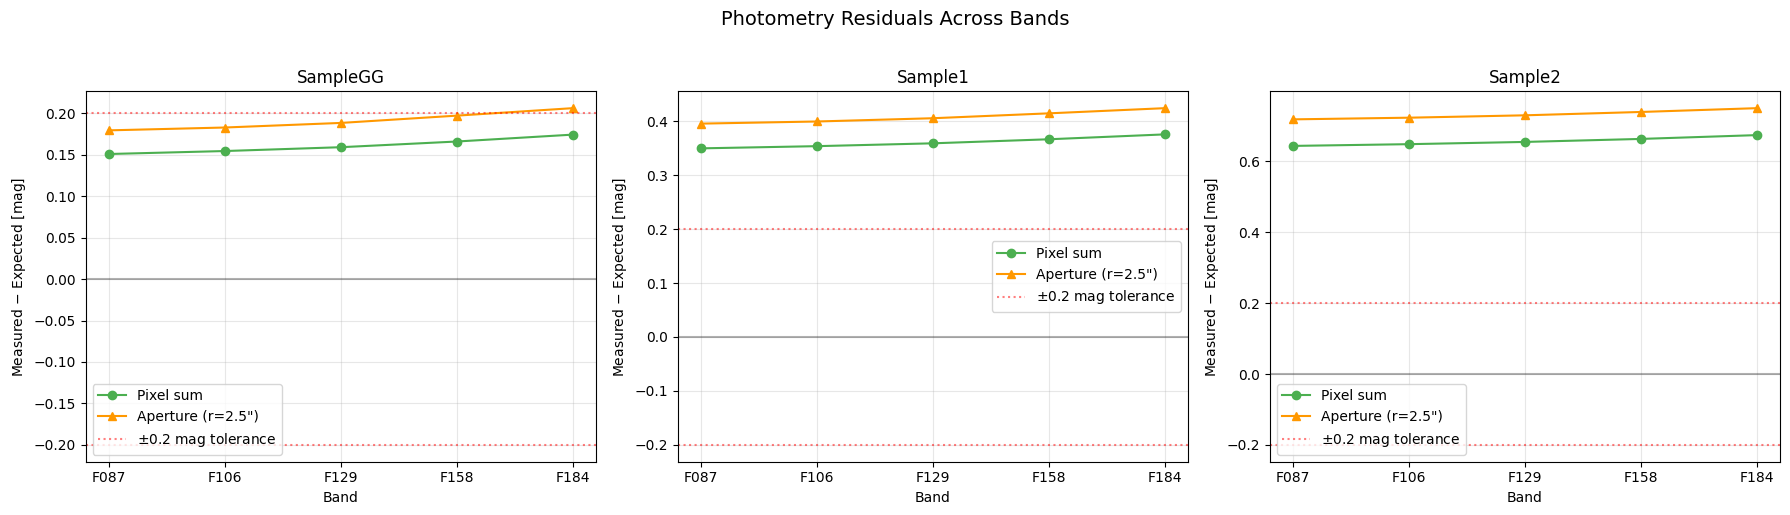

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(samples):
    ax = axes[i]
    res = multiband_results[name]
    
    expected = np.array(res['expected'])
    pix_resid = np.array(res['pixel_sum']) - expected
    aper_resid = np.array(res['aperture']) - expected
    
    ax.plot(roman_bands, pix_resid, 'o-', label='Pixel sum', color='#4CAF50', markersize=6)
    ax.plot(roman_bands, aper_resid, '^-', label='Aperture (r=2.5")', color='#FF9800', markersize=6)
    ax.axhline(0, color='k', ls='-', alpha=0.3)
    ax.axhline(0.2, color='r', ls=':', alpha=0.5, label='$\\pm$0.2 mag tolerance')
    ax.axhline(-0.2, color='r', ls=':', alpha=0.5)
    
    ax.set_xlabel('Band')
    ax.set_ylabel('Measured $-$ Expected [mag]')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Photometry Residuals Across Bands', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Summary

**Part 1** demonstrated all six `test_flux.py` tests interactively:
1. Noiseless exposure conserves total flux (within quantization error)
2. Lens + source surface brightness pieces sum exactly to the total image
3. Lens flux recovers the input lens magnitude (within 0.2 mag from FOV truncation)
4. Lensed source is brighter than the unlensed source (magnification)
5. Total maggies equals the sum of component maggies (flux is additive in linear space)
6. Exposure counts match `get_flux() * exposure_time` to < 0.1%

**Part 2** performed aperture photometry on the lensing galaxies of SampleGG, Sample1, and Sample2:
- **Pixel-sum photometry** closely matches the input `get_lens_magnitude(band)` (offset from finite FOV truncation of the Sersic profile)
- **Aperture photometry** converges toward the input magnitude as the aperture grows, with residual offsets from flux outside the aperture
- Multi-band verification confirms consistency across F087, F106, F129, F158, and F184